
# Lab 3 Assignment: Exploratory Data Analysis (EDA)
Dataset: DEEP-VOICE (AI-Generated vs. Real Speech)


In [1]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

# 2. Loading the Dataset
The dataset consists of audio feature records extracted from one-second windows of speech. Each row represents a single audio segment categorized as either authentic ("REAL") or synthetically generated ("FAKE").

In [3]:
# 2. Loading Dataset
df = pd.read_csv("/kaggle/input/datasets/fayalotaibi77/deepfake-voice-recognition/DATASET-balanced.csv")

# Display first 7 rows
df.head(7)

,chroma_stft,rms,spectral_centroid,spectral_bandwidth,rolloff,zero_crossing_rate,mfcc1,mfcc2,mfcc3,mfcc4,...,mfcc12,mfcc13,mfcc14,mfcc15,mfcc16,mfcc17,mfcc18,mfcc19,mfcc20,LABEL
0,0.338055,0.027948,2842.948867,4322.916759,6570.586186,0.041050,-462.169586,90.311272,19.073769,24.046888,...,-6.686564,0.902086,-7.251551,-1.198342,4.747403,-4.986279,0.953935,-5.013138,-6.779060,FAKE
1,0.443766,0.037838,2336.129597,3445.777044,3764.949874,0.047730,-409.413422,120.348808,-7.161531,5.114784,...,-2.131157,-6.876417,-1.359395,0.326401,-5.420016,-2.109968,-1.757634,-9.537907,-8.494421,FAKE
2,0.302528,0.056578,2692.988386,2861.133180,4716.610271,0.080342,-318.996033,120.490273,-24.625771,23.891073,...,-5.853725,-3.724773,-6.627182,-5.117002,-6.072106,-0.994653,-1.617120,-3.922354,-7.033001,FAKE
3,0.319933,0.031504,2241.665382,3503.766175,3798.641521,0.047180,-404.636749,136.320908,2.308172,-3.907071,...,-1.898315,-2.046493,-7.176277,-3.293508,4.209121,0.121835,-5.407063,-3.654926,-3.274857,FAKE
4,0.420055,0.016158,2526.069123,3102.659519,5025.077899,0.051905,-410.497925,152.731400,-18.266771,51.993462,...,-1.952340,0.810868,6.238493,6.555839,7.535542,2.849219,2.616843,-1.793357,-5.060998,FAKE
5,0.442880,0.012317,3952.880304,3702.717829,7104.089991,0.115387,-498.179657,97.245255,-21.382017,45.624386,...,-6.466366,2.856888,-0.157036,-2.824058,0.383832,-1.089466,2.998828,-5.218136,-1.423959,FAKE
6,0.453897,0.021782,4178.072150,3698.644769,7508.242075,0.131647,-410.383087,97.026733,-22.508402,49.689598,...,-5.320498,-4.209944,-2.051953,-0.714617,-7.889741,-0.377954,-8.421499,-5.800948,-12.060839,FAKE


From the first few rows, we can observe that the columns contain numerical audio features (MFCCs, Spectral Centroid, etc.), while the LABEL column is categorical. This indicates that the data is already pre-processed into numerical vectors suitable for analysis.

# 3. Data Type Verification


In [4]:
# 3. Data Type Verification
# viewing the data types of columns
df.dtypes

chroma_stft           float64
rms                   float64
spectral_centroid     float64
spectral_bandwidth    float64
rolloff               float64
zero_crossing_rate    float64
mfcc1                 float64
mfcc2                 float64
mfcc3                 float64
mfcc4                 float64
mfcc5                 float64
mfcc6                 float64
mfcc7                 float64
mfcc8                 float64
mfcc9                 float64
mfcc10                float64
mfcc11                float64
mfcc12                float64
mfcc13                float64
mfcc14                float64
mfcc15                float64
mfcc16                float64
mfcc17                float64
mfcc18                float64
mfcc19                float64
mfcc20                float64
LABEL                  object
dtype: object

The data type inspection shows that all acoustic features are stored as float64, while the target variable is an object. Thus, there are no currency symbols or date formatting issues here, and the numerical values are ready for calculation.

# 4. Check Missing Values & Duplicates

In [8]:
# 4. Check Missing Values & Duplicates
print("Missing values:\n", df.isna().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values:
 chroma_stft           0
rms                   0
spectral_centroid     0
spectral_bandwidth    0
rolloff               0
zero_crossing_rate    0
mfcc1                 0
mfcc2                 0
mfcc3                 0
mfcc4                 0
mfcc5                 0
mfcc6                 0
mfcc7                 0
mfcc8                 0
mfcc9                 0
mfcc10                0
mfcc11                0
mfcc12                0
mfcc13                0
mfcc14                0
mfcc15                0
mfcc16                0
mfcc17                0
mfcc18                0
mfcc19                0
mfcc20                0
LABEL                 0
dtype: int64

Number of duplicate rows: 0


The analysis shows that there are no missing values or duplicate records in this dataset. This high level of data integrity ensures that summary statistics and future models will not be biased by null entries or repeated data points.

# 5. Number of Rows and Columns

In [9]:
# 5. Number of Rows and Columns
print("Shape (rows, columns): ", df.shape)
print("Number of rows: ", df.shape[0])
print("Number of columns: ", df.shape[1])

Shape (rows, columns):  (11778, 27)
Number of rows:  11778
Number of columns:  27


The dataset consists of 11,778 rows and 27 columns. This sample size is robust enough to identify clear patterns between human and AI voices without being computationally expensive.

# 6. Descriptive Summary Statistics

In [10]:
# 6. Descriptive Summary Statistics
# Statistical summary
df.describe(include='all')

,chroma_stft,rms,spectral_centroid,spectral_bandwidth,rolloff,zero_crossing_rate,mfcc1,mfcc2,mfcc3,mfcc4,...,mfcc12,mfcc13,mfcc14,mfcc15,mfcc16,mfcc17,mfcc18,mfcc19,mfcc20,LABEL
count,11778.000000,11778.000000,11778.000000,11778.000000,11778.000000,11778.000000,11778.000000,11778.000000,11778.000000,11778.000000,...,11778.000000,11778.000000,11778.000000,11778.000000,11778.000000,11778.000000,11778.000000,11778.000000,11778.000000,11778
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FAKE
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5889
mean,0.421925,0.037894,2719.201373,3050.299988,4977.617722,0.070821,-382.562312,145.056311,-24.699932,21.311292,...,-4.439806,-1.657739,-2.107442,-2.606924,-1.641709,-3.320340,-3.117110,-2.754034,-4.427346,NaN
std,0.069392,0.028071,1066.754739,872.258653,2170.158448,0.039292,79.593413,36.188506,27.728976,22.480432,...,6.614913,5.121732,5.347953,4.909579,5.627377,4.597079,4.976511,4.957660,5.478806,NaN
min,0.200353,0.000043,756.163229,1096.903152,1063.964279,0.015504,-1055.002197,-83.816765,-132.491104,-47.770000,...,-30.168062,-19.717999,-21.553347,-28.876045,-20.307486,-22.753056,-19.623880,-23.890470,-25.099829,NaN
25%,0.372330,0.015098,2062.875836,2569.289971,3448.144178,0.045749,-432.928848,120.522711,-35.550402,3.635681,...,-8.233070,-5.178427,-5.642066,-5.760252,-4.868709,-6.435052,-5.862841,-5.514250,-7.463774,NaN
50%,0.417708,0.031870,2579.963841,3055.863462,4683.958018,0.060237,-365.756241,145.970162,-19.164229,22.218458,...,-4.186015,-1.530670,-2.320350,-2.447045,-0.862829,-3.230387,-2.957088,-2.726495,-3.839427,NaN
75%,0.467741,0.054046,3283.857559,3581.271953,6211.301553,0.085149,-321.772781,168.321331,-6.235028,37.017731,...,-0.266044,1.794835,1.569430,0.837690,2.043472,-0.293191,0.068411,0.495779,-0.787292,NaN


The descriptive statistics provide an overview of the acoustic ranges. For example, spectral_centroid values range from ~756 to ~17,685, suggesting a wide variety of voice pitches and frequencies. The LABEL summary confirms the dataset is balanced.

# 7. Univariate Analysis
# Distribution of Spectral Centroid (Audio Brightness)

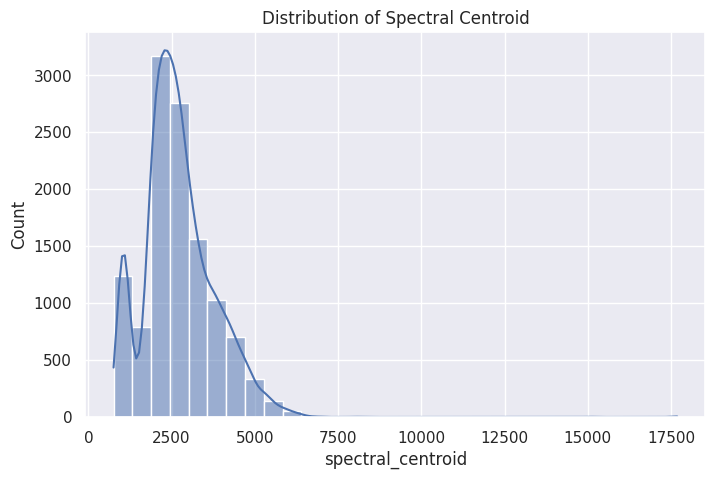

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['spectral_centroid'], bins=30, kde=True)
plt.title("Distribution of Spectral Centroid")
plt.show()

The distribution of the spectral centroid is slightly right-skewed. Most speech segments center around 2,500Hz, representing the standard human vocal range, while the tail indicates higher-frequency "brighter" sounds or potential digital artifacts in deepfakes.

# 8. Bivariate Analysis
# Spectral Centroid by Label (Real vs. Fake)

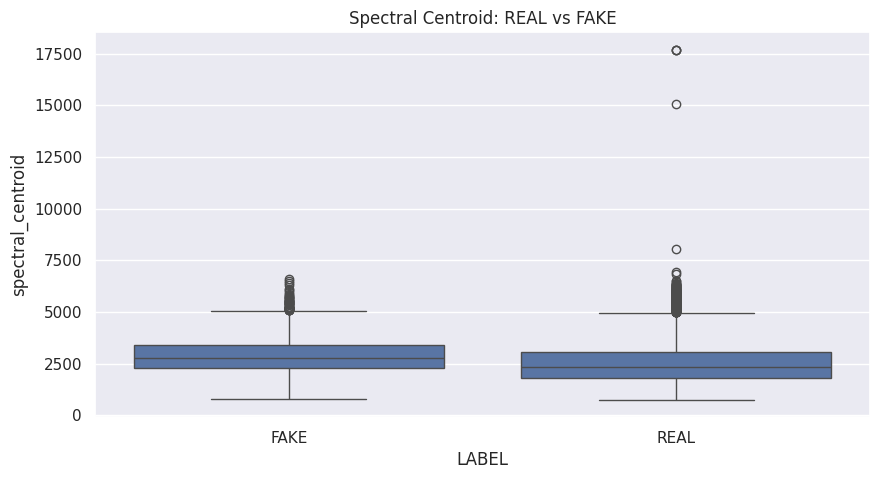

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(x='LABEL', y='spectral_centroid', data=df)
plt.title("Spectral Centroid: REAL vs FAKE")
plt.show()

The box plot reveals differences in frequency distribution between human and AI voices. If the "FAKE" category shows a different median or more outliers, it suggests that AI-generated speech may lack the natural frequency constraints of a human vocal tract.

# Correlation Matrix

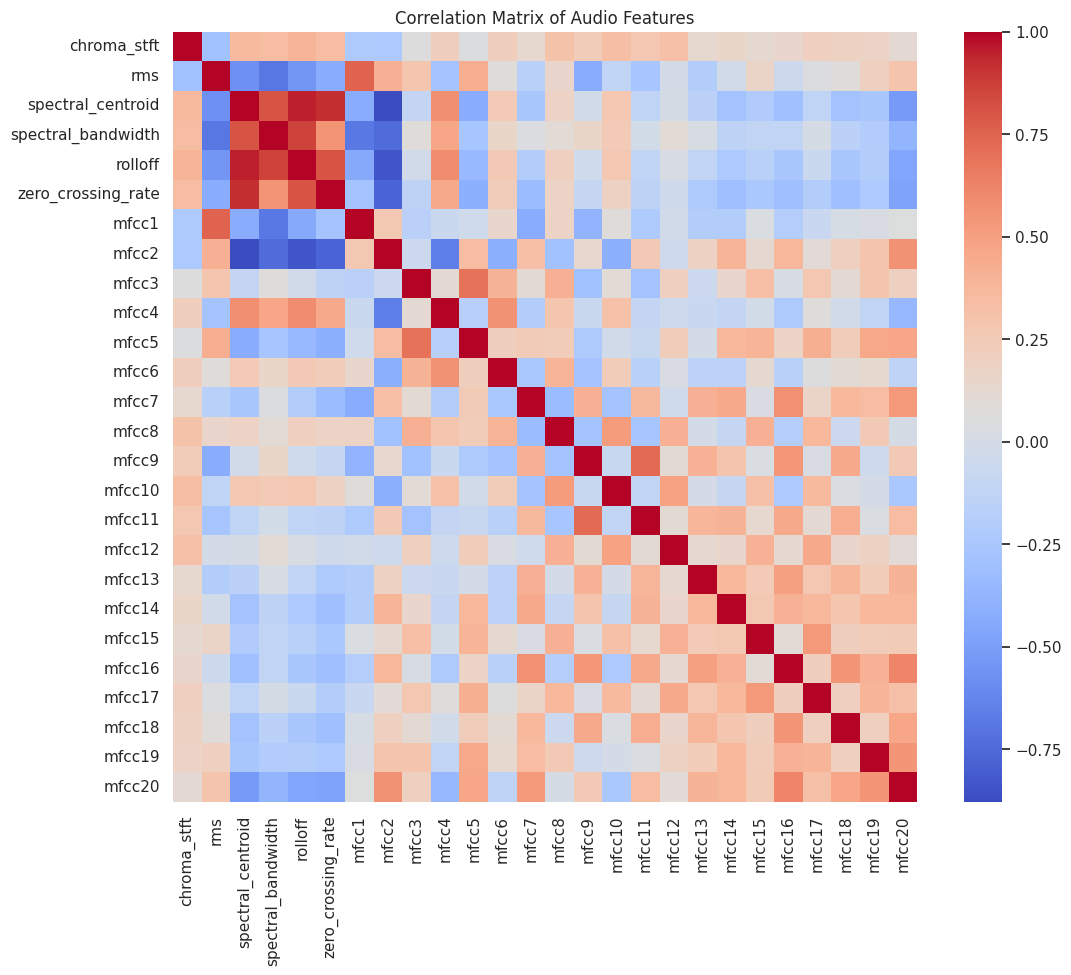

In [13]:
plt.figure(figsize=(12,10))
sns.heatmap(df.drop(columns=['LABEL']).corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Matrix of Audio Features")
plt.show()

The heatmap shows strong positive correlations between spectral_centroid, rolloff, and spectral_bandwidth. This indicates that these features are physically related in how they describe the "sharpness" and frequency range of the audio signals.

# Note on Time-Based Analysis:
> This dataset contains extracted acoustic features from isolated audio segments and does not include chronological timestamps or dates. Therefore, time-series trend analysis (as shown in the sales lab) is not applicable to this data.

# Conclusion
Based on this EDA, the DEEP-VOICE dataset is clean, balanced, and contains distinct numerical differences between classes. The strong correlations between certain spectral features suggest that future modeling could benefit from feature selection to reduce redundancy while maintaining the ability to detect synthetic speech patterns.

*End of Lab 3 Assignment.*